<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Repaso: Algoritmos de Aprendizaje Automático</h1>
    <h3>Clasificación y panorama general</h3>
</div>

## ¿Qué es el Aprendizaje Automático?

El **Aprendizaje Automático** (*Machine Learning*, ML) es la rama de la Inteligencia Artificial que permite a los sistemas **aprender patrones a partir de los datos** sin ser programados explícitamente para cada tarea.

>  **Idea central:** en lugar de escribir reglas a mano, alimentamos datos a un algoritmo que **infiere** las reglas por sí mismo.

```mermaid
flowchart LR
    subgraph PC["Programación clásica"]
        direction LR
        R1[Reglas] --> P[Programa]
        D1[Datos] --> P
        P --> O1[Resultado]
    end
    subgraph ML["Aprendizaje Automático"]
        direction LR
        D2[Datos] --> A[Algoritmo]
        O2[Resultado] --> A
        A --> M[Modelo -reglas aprendidas-]
    end
    PC -.transición.-> ML
```

Este notebook es un **repaso** de cómo se clasifican los algoritmos de ML, para ubicar en el mapa los algoritmos avanzados que veremos a continuación.


## Clasificación de los algoritmos de ML

Los algoritmos de ML se agrupan según **cómo aprenden** (qué tipo de retroalimentación reciben):

```mermaid
flowchart TD
    ML([APRENDIZAJE AUTOMÁTICO])
    ML --> S[Supervisado<br/>datos etiquetados]
    ML --> U[No supervisado<br/>sin etiqueta]
    ML --> SS[Semi-supervisado<br/>pocas etiquetas]
    ML --> R[Por refuerzo<br/>recompensa]
    ML --> AS[Auto-supervisado]

    S --> S1[Clasificación]
    S --> S2[Regresión]

    U --> U1[Clustering]
    U --> U2[Reducción de dimensión]
    U --> U3[Reglas de asociación]

    classDef root fill:#000047,color:#2E9AFE,stroke:#000;
    classDef sup fill:#eaf3ff,stroke:#2E9AFE,color:#000;
    classDef uns fill:#e8f8f3,stroke:#2E9AFE,color:#000;
    class ML root;
    class S,S1,S2 sup;
    class U,U1,U2,U3 uns;
```

| Paradigma | ¿Datos etiquetados? | Objetivo | Ejemplo de uso |
|---|---|---|---|
| **Supervisado** | Sí, `(X, y)` | Predecir una salida `y` | Detectar spam, predecir precios |
| **No supervisado** | No, solo `X` | Descubrir estructura | Segmentar clientes |
| **Semi-supervisado** | Pocas etiquetas | Aprovechar datos sin etiquetar | Clasificar imágenes con pocas etiquetas |
| **Por refuerzo** | Recompensas | Aprender una política | Robótica, juegos, control |


## Aprendizaje Supervisado

Aprende de datos **etiquetados**: cada ejemplo de entrada `X` tiene una respuesta conocida `y`. Se divide en dos grandes tareas:

### 1. Clasificación (salida categórica)
Predecir una **etiqueta discreta** (clase).

| Algoritmo | Idea clave |
|---|---|
| Regresión logística | Frontera lineal + función sigmoide |
| k-Vecinos (k-NN) | Vota según los vecinos más cercanos |
| Máquinas de Soporte Vectorial (SVM) | Máximo margen entre clases |
| Árboles de decisión | Reglas jerárquicas si/no |
| Random Forest | Ensamble de muchos árboles |
| **Gradient Boosting** | Árboles secuenciales que corrigen errores |

### 2. Regresión (salida continua)
Predecir un **valor numérico**.

| Algoritmo | Idea clave |
|---|---|
| Regresión lineal | Ajusta una recta/plano |
| Regresión Ridge / Lasso | Regresión lineal con regularización |
| SVR | SVM para regresión |
| Árboles / Random Forest / **Gradient Boosting** | Modelos no lineales potentes |

> **Gradient Boosting** (XGBoost, LightGBM, CatBoost) es hoy el rey del **aprendizaje supervisado sobre datos tabulares**. Lo veremos en detalle en un notebook aparte.

## Aprendizaje No Supervisado

No hay etiquetas: el algoritmo busca **estructura oculta** en los datos `X`.

### 1. Clustering (agrupamiento)
Agrupar ejemplos similares en **grupos** (*clusters*).

| Familia | Algoritmos | Idea clave |
|---|---|---|
| Basado en centroides | K-Means, K-Medoids | Grupos alrededor de centros |
| Jerárquico | Agglomerative, Divisive | Árbol de agrupaciones (dendrograma) |
| **Basado en densidad** | DBSCAN, HDBSCAN, OPTICS | Regiones densas separadas por zonas vacías |
| **Probabilístico** | Gaussian Mixture Models | Cada punto pertenece a los grupos con cierta probabilidad |

### 2. Reducción de dimensionalidad
Comprimir los datos conservando la información relevante: **PCA**, **t-SNE**, **UMAP**, Autoencoders.

### 3. Reglas de asociación
Descubrir relaciones frecuentes: **Apriori**, **FP-Growth** (análisis de carrito de compra).

> En los notebooks siguientes profundizaremos en el **clustering basado en densidad** (DBSCAN, HDBSCAN, OPTICS) y en el **clustering probabilístico** (GMM y mezclas bayesianas).

## Otros paradigmas

- **Semi-supervisado:** combina pocos datos etiquetados con muchos sin etiquetar (p. ej. *self-training*, *label propagation*).
- **Auto-supervisado:** genera sus propias etiquetas a partir de los datos (base de los grandes modelos modernos de lenguaje y visión).
- **Aprendizaje por refuerzo:** un **agente** aprende a tomar decisiones interactuando con un **entorno** para maximizar una **recompensa** (lo veremos en el Módulo 3).

## ¿Cómo elegir un algoritmo?

Una guía rápida según el problema:

| ¿Tienes etiquetas? | ¿Qué quieres? | Familia recomendada |
|---|---|---|
| Sí | Predecir una categoría | Clasificación (Boosting, SVM, RF) |
| Sí | Predecir un número | Regresión (Boosting, lineal, RF) |
| No | Agrupar por similitud/densidad | Clustering (K-Means, DBSCAN, GMM) |
| No | Visualizar / comprimir | Reducción de dimensión (PCA, UMAP) |
| Recompensas | Aprender a actuar | Aprendizaje por refuerzo |

> **No existe el mejor algoritmo universal** (*No Free Lunch Theorem*). La elección depende de los datos, el objetivo y las restricciones (interpretabilidad, tamaño, tiempo).

## Ejemplo: comparación sencilla de un dataset generado aleatoriamente

Comparemos un clasificador **supervisado** y un algoritmo de **clustering no supervisado** sobre el mismo dataset para ilustrar la diferencia.

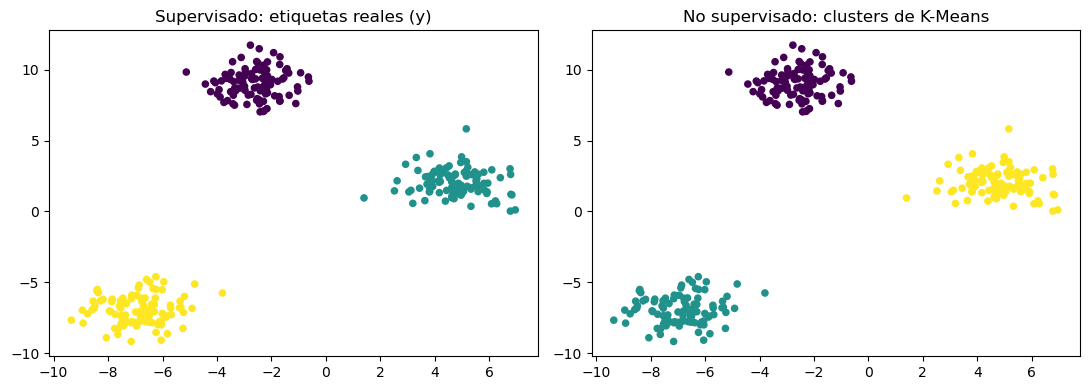

In [1]:
# Ajustes para Windows: deben ir ANTES de importar numpy / scikit-learn
import os
os.environ["OMP_NUM_THREADS"] = "2"          # evita el memory leak de KMeans (Windows + MKL)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # tolera dos runtimes OpenMP (libiomp + libomp)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning, module="threadpoolctl")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans

# Datos de juguete con 3 grupos
X, y = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Supervisado: conoce las etiquetas y
clf = LogisticRegression(max_iter=1000).fit(X, y)

# No supervisado: NO usa las etiquetas, solo X
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=20)
ax[0].set_title('Supervisado: etiquetas reales (y)')
ax[1].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', s=20)
ax[1].set_title('No supervisado: clusters de K-Means')
plt.tight_layout()
plt.show()


- El ML se clasifica principalmente en **supervisado**, **no supervisado**, **semi-supervisado** y **por refuerzo**.
- El **supervisado** usa etiquetas y resuelve **clasificación** y **regresión**.
- El **no supervisado** descubre estructura: **clustering**, **reducción de dimensión** y **asociación**.
